<a href="https://colab.research.google.com/github/kwerulik/Computer-Vision-Waste-Classification/blob/main/ML_Projekt_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("hassnainzaidi/garbage-classification")

# print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# train_dir = os.path.join(path, "Garbage classification", "train")
# val_dir = os.path.join(path, "Garbage classification", "val")
# test_dir = os.path.join(path, "Garbage classification", "test")

data_dir = os.path.join(path, "Garbage classification/Garbage classification")


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
  except RuntimeError as e:
    print(e)

In [ ]:
def set_datasets(img_size, batch_size):

  train_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=42,
        batch_size=batch_size,
        image_size=img_size,
        pad_to_aspect_ratio=True,
    )

  class_names = train_dataset.class_names

  val_test_pool = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        batch_size=batch_size,
        image_size=img_size,
        pad_to_aspect_ratio=True,
    )

  pool_batches = tf.data.experimental.cardinality(val_test_pool)
  val_batches = pool_batches // 2

  val_dataset = val_test_pool.take(val_batches)
  test_dataset = val_test_pool.skip(val_batches)

  train_paths = train_dataset.file_paths
  val_test_paths = val_test_pool.file_paths
  leaked_files = set(train_paths).intersection(set(val_test_paths))
  print(f"Number of leaked files: {len(leaked_files)}")

  return train_dataset, val_dataset, test_dataset, class_names

In [ ]:
def plot_history(history, title, file_prefix):
    os.makedirs("results/plots/accuracy", exist_ok=True)
    os.makedirs("results/plots/loss", exist_ok=True)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.title(title + " - accuracy")
    plt.legend()
    acc_path = f"results/plots/accuracy/{file_prefix}_accuracy.png"
    plt.savefig(acc_path)
    plt.show()
    plt.close('all')

    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.title(title + " - loss")
    plt.legend()
    loss_path = f"results/plots/loss/{file_prefix}_loss.png"
    plt.savefig(loss_path)
    plt.show()
    plt.close('all')


In [ ]:
def create_model(num_layers, img_size, filter_count, kernel_size, neuron_count):
  model_elements = [
        layers.Rescaling(1./255, input_shape=(img_size[0], img_size[1], 3))
    ]
  for i in range(num_layers):
      model_elements.append(
          layers.Conv2D(
              filters=filter_count * (2**i),
              kernel_size=kernel_size,
              activation="relu",
          )
      )
      model_elements.append(layers.MaxPooling2D(pool_size=(2, 2)))

  model_elements.extend([
        layers.Flatten(),
        layers.Dense(neuron_count, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(6, activation="softmax")
    ])
  cnn_model = models.Sequential(model_elements)

  cnn_model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

  cnn_model.summary()
  return cnn_model

In [ ]:
def run_model(model, epochs, train_dataset, val_dataset, test_dataset):
  early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
  )

  history = model.fit(
      train_dataset,
      validation_data=val_dataset,
      epochs=epochs,
      callbacks=[early_stopping],

  )

  title = f"CNN Layers: {layer_count} | Size: {img_size[0]}x{img_size[1]} | Filters: {filter_count} | Neurons: {neuron_count}"
  file_prefix = f"cnn_l{layer_count}_{img_size[0]}x{img_size[1]}_f{filter_count}_n{neuron_count}"


  plot_history(history, title, file_prefix)
  test_results = model.evaluate(test_dataset)

  val_loss_history = history.history["val_loss"]
  best_epoch_idx = val_loss_history.index(min(val_loss_history))

  final_epoch = best_epoch_idx + 1
  param_count = model.count_params()

  last_train_acc = history.history["accuracy"][best_epoch_idx]
  last_val_acc = history.history["val_accuracy"][best_epoch_idx]
  last_train_loss = history.history["loss"][best_epoch_idx]
  last_val_loss = history.history["val_loss"][best_epoch_idx]

  test_acc = test_results[1]
  test_loss = test_results[0]

  csv_data = [param_count, final_epoch, last_train_acc, last_train_loss, last_val_acc, last_val_loss, test_acc, test_loss]

  return history, csv_data


In [ ]:
## DANE
img_sizes = [
    (64,64),
    # (128,128),
    # (256,256)
    ]
filter_counts = [
    32,
    # 64,
    # 128
    ]
neuron_counts = [
    # 32,
    # 64,
    256,
    # 512,
    # 1024
    ]
layer_counts = [
    # 1,
    # 2,
    3,
    ]

## Nie zmieniac
BATCH_SIZE = 32
KERNEL_SIZE = (3,3)
epochs = 30

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Number of leaked files: 0
img_size: (64, 64), filter_count: 32, neuron_count: 256


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,694 (4.86 MB)

 Trainable params: 1,274,694 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.3017 - loss: 1.6327 - val_accuracy: 0.3984 - val_loss: 1.4861
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.4545 - loss: 1.3703 - val_accuracy: 0.3750 - val_loss: 1.4575
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4777 - loss: 1.2805 - val_accuracy: 0.4883 - val_loss: 1.2714
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5564 - loss: 1.1608 - val_accuracy: 0.5000 - val_loss: 1.2506
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5890 - loss: 1.0974 - val_accuracy: 0.5078 - val_loss: 1.1456
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6207 - loss: 1.0244 - val_accuracy: 0.5898 - val_loss: 1.0488
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6662 - loss: 0.9054 - val_accuracy: 0.5703 - val_loss: 1.1088
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6939 - loss: 0.8216 - val_accuracy: 0.6562 - v

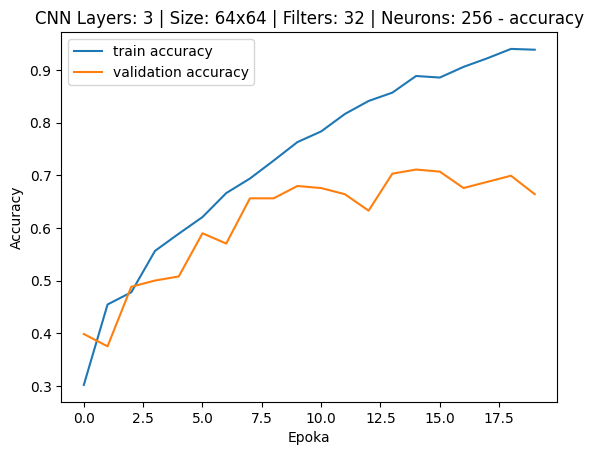

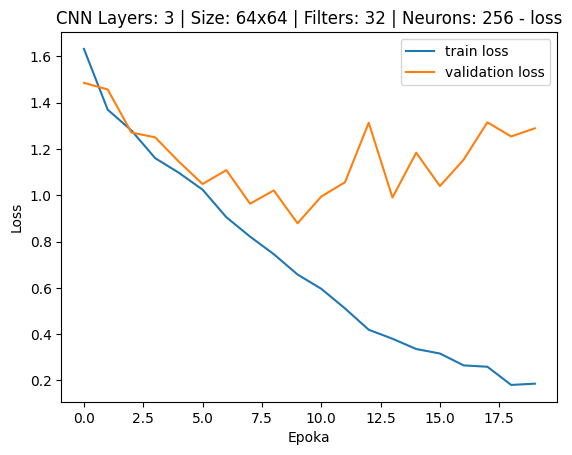

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7068 - loss: 0.8334


In [ ]:
csv_labels = ["model", "layer count", "img size", "filter count", "neuron count", "params", "final epoch", "train_acc", "train_loss", "val_acc", "val_loss", "test_acc", "test_loss"]

for layer_count in layer_counts:
  for img_size in img_sizes:
    train_dataset, val_dataset, test_dataset, class_names = set_datasets(img_size, BATCH_SIZE)
    for filter_count in filter_counts:
      for neuron_count in neuron_counts:
        print( f"img_size: {img_size}, filter_count: {filter_count}, neuron_count: {neuron_count}")
        model = create_model(layer_count, img_size, filter_count, KERNEL_SIZE, neuron_count)
        history, run_data = run_model(model, epochs, train_dataset, val_dataset, test_dataset)
        csv_data = ["CNN", layer_count ,f"{img_size[0]}x{img_size[1]}", filter_count, neuron_count] + run_data
        df = pd.DataFrame([csv_data], columns=csv_labels)

        csv_filename = "results/results.csv"
        if os.path.exists(csv_filename):
            df.to_csv(csv_filename, mode='a', header=False, index=False)
        else:
            df.to_csv(csv_filename, index=False)
        # del model, history
        print("="*64)
    # del train_dataset, val_dataset, test_dataset, class_names


In [ ]:
!zip -r /content/results.zip /content/results
from google.colab import files
files.download("/content/results.zip")



updating: content/results/ (stored 0%)
updating: content/results/plots/ (stored 0%)
updating: content/results/plots/accuracy/ (stored 0%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f32_n512_accuracy.png (deflated 7%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f32_n1024_accuracy.png (deflated 8%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f128_n1024_accuracy.png (deflated 7%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f128_n512_accuracy.png (deflated 7%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f64_n512_accuracy.png (deflated 7%)
updating: content/results/plots/accuracy/cnn_l1_128x128_f32_n512_accuracy.png (deflated 8%)
updating: content/results/plots/accuracy/cnn_l1_64x64_f64_n1024_accuracy.png (deflated 8%)
updating: content/results/plots/accuracy/cnn_l1_128x128_f64_n512_accuracy.png (deflated 7%)
updating: content/results/plots/accuracy/cnn_l1_128x128_f32_n1024_accuracy.png (deflated 8%)
updating: content/results/plots/loss/ (s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


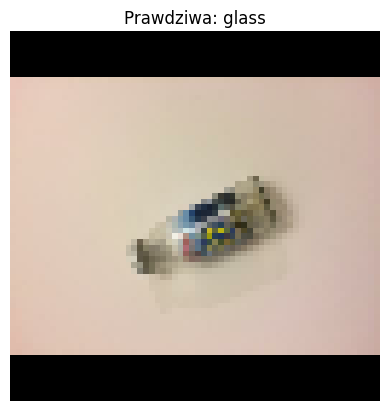

Predykcja: glass
Pewność: 0.77


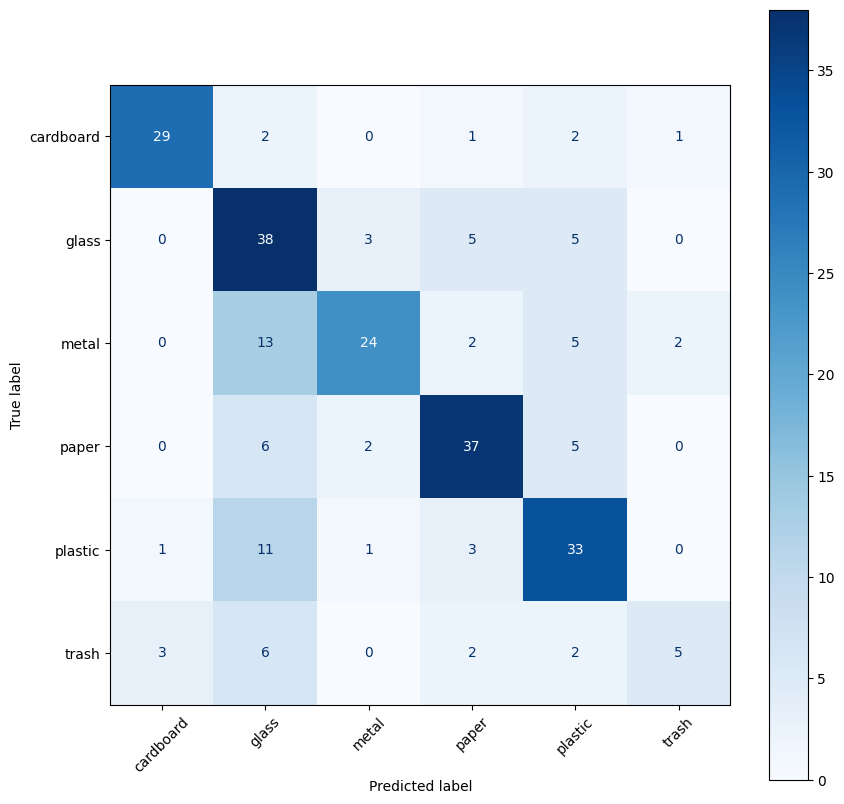

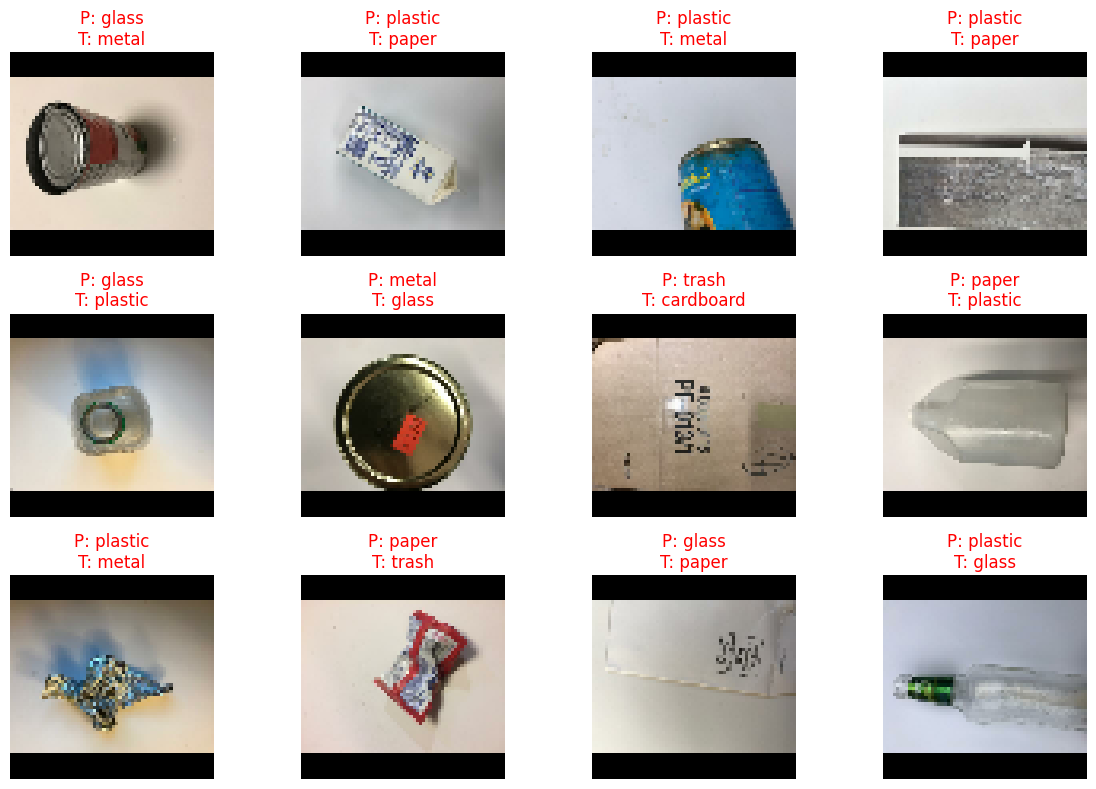

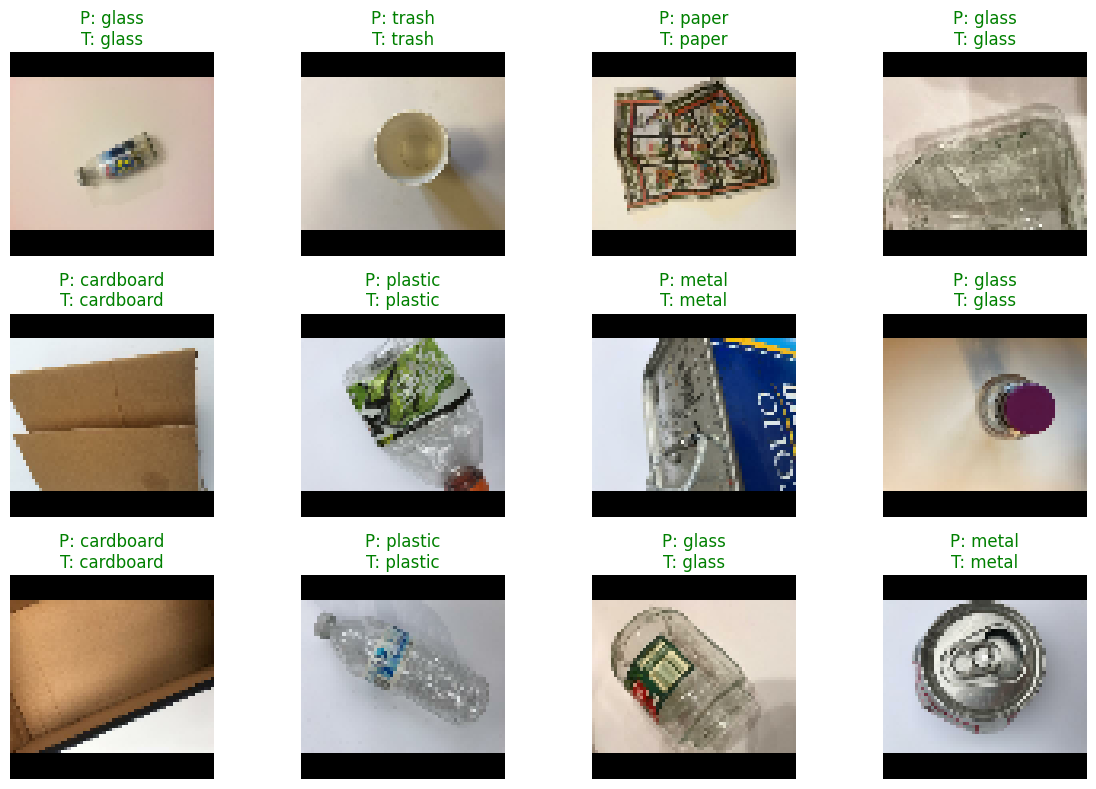

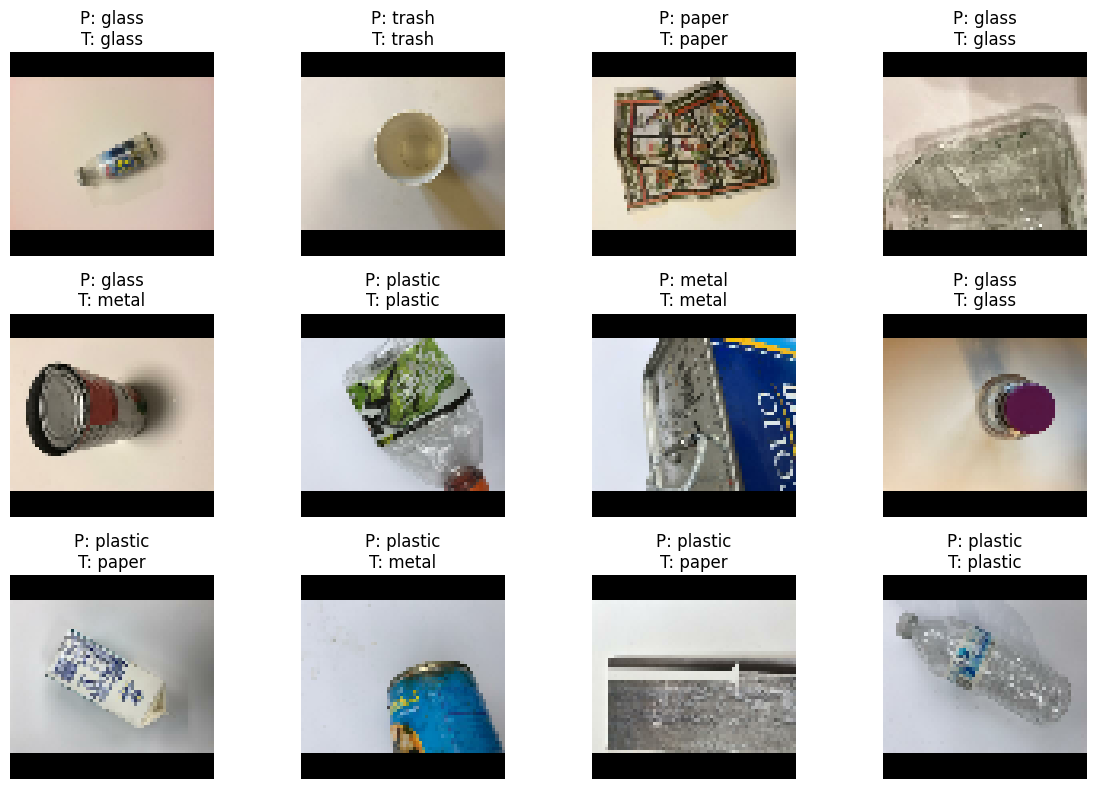

In [ ]:
X_test_list = []
y_test_list = []

for images, labels in test_dataset:
    X_test_list.append(images.numpy())
    y_test_list.append(labels.numpy())

X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

index = 0

plt.imshow(X_test[index].astype("uint8"))
plt.title(f"Prawdziwa: {class_names[y_test[index]]}")
plt.axis("off")
plt.show()

print(f"Predykcja: {class_names[predicted_classes[index]]}")
print(f"Pewność: {np.max(predictions[index]):.2f}")

cm = confusion_matrix(y_test, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap=plt.cm.Blues)
plt.show()


wrong_indices = np.where(predicted_classes != y_test)[0]
plt.figure(figsize=(12, 8))
for i, idx in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"P: {class_names[predicted_classes[idx]]}\nT: {class_names[y_test[idx]]}", color='red')
    plt.axis("off")
plt.tight_layout()
plt.show()

correct_indices = np.where(predicted_classes == y_test)[0]
plt.figure(figsize=(12, 8))
for i, idx in enumerate(correct_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"P: {class_names[predicted_classes[idx]]}\nT: {class_names[y_test[idx]]}", color='green')
    plt.axis("off")
plt.tight_layout()
plt.show()

indices = np.where(predicted_classes)[0]
plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"P: {class_names[predicted_classes[idx]]}\nT: {class_names[y_test[idx]]}", color='black')
    plt.axis("off")
plt.tight_layout()
plt.show()